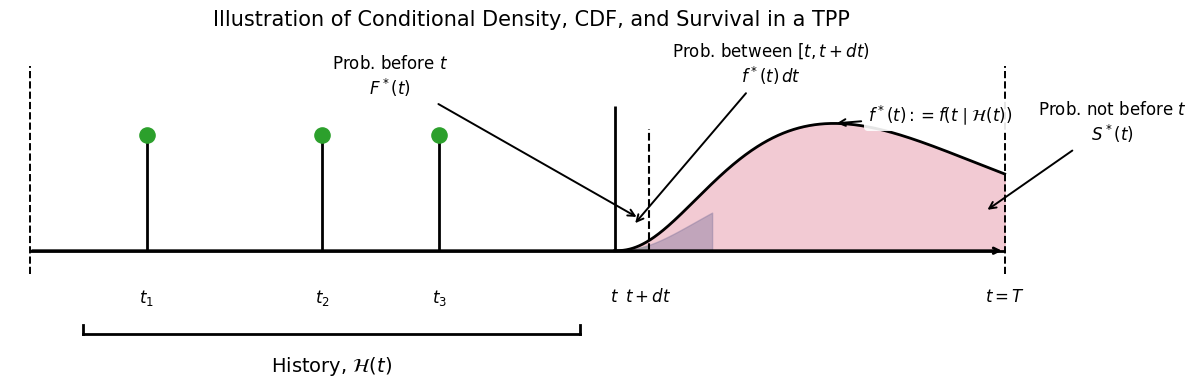

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def draw_tpp_likelihood_illustration_smooth(
    T=10.0,
    event_times=(1.2, 3.0, 4.2),
    t=6.0,
    dt=0.35,
    save_path=None
):
    fig, ax = plt.subplots(figsize=(12, 4))

    # --- Base timeline ---
    ax.hlines(0, 0, T, color="black", linewidth=2)
    ax.annotate("", xy=(T, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", lw=2, color="black"))

    # --- Past events (ticks + green dots) ---
    for i, ti in enumerate(event_times, start=1):
        ax.vlines(ti, 0, 1.0, color="black", linewidth=2)
        ax.scatter([ti], [1.0], s=120, color="#2ca02c", zorder=5)
        ax.text(ti, -0.32, rf"$t_{i}$", ha="center", va="top", fontsize=12)

    # --- Dashed boundaries at 0 and T ---
    ax.vlines(0, -0.2, 1.6, color="black", linestyle="--", linewidth=1.4)
    ax.vlines(T, -0.2, 1.6, color="black", linestyle="--", linewidth=1.4)
    ax.text(T, -0.32, "$t=T$", ha="center", va="top", fontsize=12)

    # --- Mark current time t and t+dt ---
    ax.vlines(t, 0, 1.25, color="black", linewidth=2)
    ax.vlines(t+dt, 0, 1.05, color="black", linewidth=1.5, linestyle="--")
    ax.text(t, -0.32, "$t$", ha="center", va="top", fontsize=12)
    ax.text(t+dt, -0.32, "$t+dt$", ha="center", va="top", fontsize=12)

    # --- Smooth conditional density curve after t ---
    xs = np.linspace(t, T, 600)
    u = xs - t

    # Gamma-like smooth bump (illustrative, not model-specific)
    alpha, beta = 3.5, 0.9
    bump = (u**(alpha-1)) * np.exp(-u/beta)
    bump /= bump.max()
    bump *= 1.1

    ax.plot(xs, bump, color="black", linewidth=2)

    # --- Regions ---
    # (a) "before t" piece: show left wedge under a small segment after t
    xs_left = np.linspace(t, t + 1.0, 160)
    u_left = xs_left - t
    bump_left = (u_left**(alpha-1)) * np.exp(-u_left/beta)
    bump_left /= bump.max()
    bump_left *= 1.1
    ax.fill_between(xs_left, 0, bump_left, color="#4c78a8", alpha=0.45)

    # (b) small slice [t, t+dt)
    xs_slice = np.linspace(t, t+dt, 80)
    u_slice = xs_slice - t
    bump_slice = (u_slice**(alpha-1)) * np.exp(-u_slice/beta)
    bump_slice /= bump.max()
    bump_slice *= 1.1
    ax.fill_between(xs_slice, 0, bump_slice, color="#72b7b2", alpha=0.70)

    # (c) survival area after t
    ax.fill_between(xs, 0, bump, color="#e07b91", alpha=0.40)

    # --- History bracket ---
    hist_start, hist_end = 0.55, t - 0.35
    yb = -0.72
    ax.plot([hist_start, hist_end], [yb, yb], color="black", linewidth=2)
    ax.plot([hist_start, hist_start], [yb, yb+0.08], color="black", linewidth=2)
    ax.plot([hist_end, hist_end], [yb, yb+0.08], color="black", linewidth=2)
    ax.text((hist_start+hist_end)/2, yb-0.18, r"History, $\mathcal{H}(t)$",
            ha="center", va="top", fontsize=14)

    # Helper for readable labels
    bbox = dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9)

    # --- Labels & arrows (repositioned to avoid overlap) ---
    ax.annotate(r"Prob. before $t$"+"\n"+r"$F^*(t)$",
                xy=(t+0.25, 0.28), xytext=(t-2.3, 1.35),
                arrowprops=dict(arrowstyle="->", lw=1.4),
                fontsize=12, ha="center", bbox=bbox)

    ax.annotate(r"Prob. between $[t, t+dt)$"+"\n"+r"$f^*(t)\,dt$",
                xy=(t+dt*0.55, 0.22), xytext=(t+1.6, 1.45),
                arrowprops=dict(arrowstyle="->", lw=1.4),
                fontsize=12, ha="center", bbox=bbox)

    peak_x = xs[np.argmax(bump)]
    peak_y = bump.max()

    ax.annotate(r"$f^*(t):= f(t\mid \mathcal{H}(t))$",
                xy=(peak_x, peak_y), xytext=(t+2.6, 1.12),
                arrowprops=dict(arrowstyle="->", lw=1.4),
                fontsize=12, ha="left", bbox=bbox)

    ax.annotate(r"Prob. not before $t$"+"\n"+r"$S^*(t)$",
                xy=(t+3.8, 0.34), xytext=(t+5.1, 0.95),
                arrowprops=dict(arrowstyle="->", lw=1.4),
                fontsize=12, ha="center", bbox=bbox)

    # --- Aesthetics ---
    ax.set_xlim(-0.2, T+0.5)
    ax.set_ylim(-1.1, 1.8)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines[['left', 'right', 'top', 'bottom']].set_visible(False)
    ax.set_title("Illustration of Conditional Density, CDF, and Survival in a TPP",
                 fontsize=15, pad=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    draw_tpp_likelihood_illustration_smooth(
        T=10.0,
        event_times=(1.2, 3.0, 4.2),
        t=6.0,
        dt=0.35,
        save_path=None  # e.g. "tpp_illustration_smooth.png"
    )
